In [ ]:
!git clone -b PINO https://github.com/AmirhosseinnnKhademi/P-20260527-PINN-Basic.git

In [1]:
import sys
#sys.path.append('/content/P-20260527-PINN-Basic')
sys.path.append('.')

from config import *
from data import get_data, get_fno_data
from model import build_model, build_fno_model
from trainer import PINNTrainer, PINOTrainer, PIFNOTrainer
from visualizer import (plot_loss, plot_solution, plot_slices,
                        plot_fno_solution, plot_fno_slices)

I0000 00:00:1780087490.497231   40518 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780087490.548456   40518 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780087493.258271   40518 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
data = get_data(N_f, N_ic, N_bc)

In [3]:
model = build_model(LAYERS)
model.summary()

E0000 00:00:1780087496.797148   40518 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,341 (5.24 KB)

 Trainable params: 1,341 (5.24 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
import tensorflow as tf

LR = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=5e-3,
    decay_steps=500,
    decay_rate=0.95)

optim = tf.keras.optimizers.Adam(learning_rate=LR)
trainer = PINNTrainer(model, optim, nu)

history = []
for epoch in range(1, Epochs + 1):
    loss = trainer.train_step(data)
    history.append(float(loss))
    if epoch % 100 == 0:
        print(f"Epoch: {epoch:5d}, Loss: {float(loss):.4e}")

Epoch:   100, Loss: 4.5050e-01


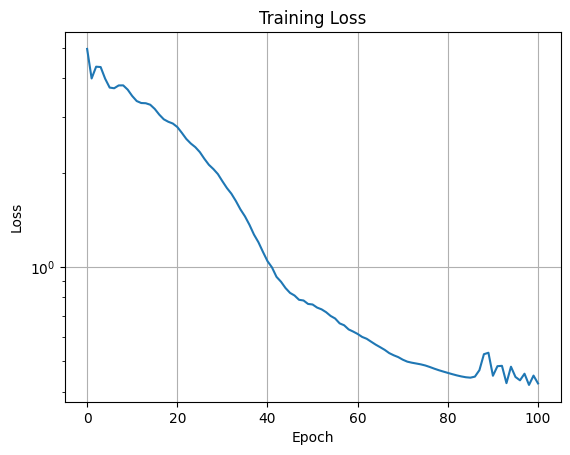

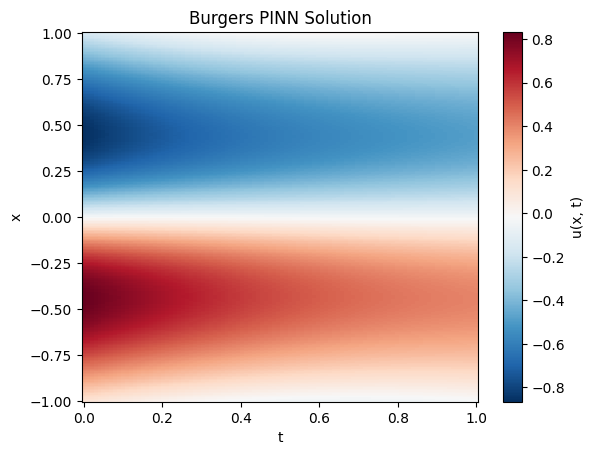

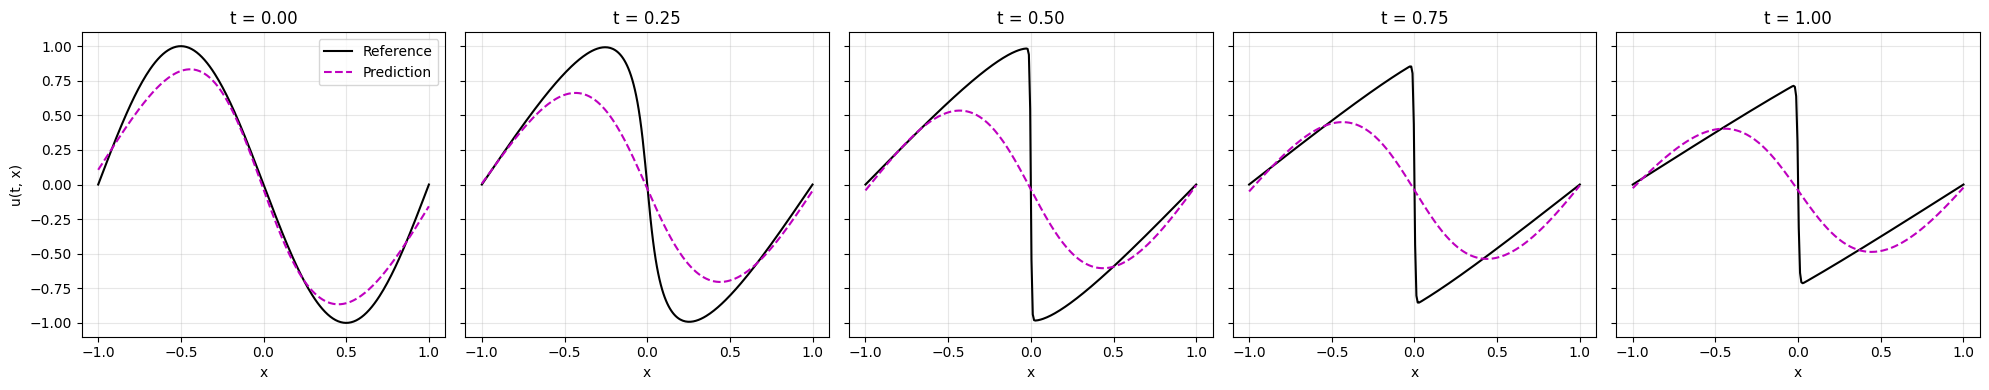

In [5]:
# Cell 6 — visualize
plot_loss(history)
plot_solution(model)
plot_slices(model)

## PINO — physics-informed neural operator (nu as input feature)

In [6]:
model_pino = build_model(LAYERS_PINO)
model_pino.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 20)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,361 (5.32 KB)

 Trainable params: 1,361 (5.32 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
LR_pino = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=5e-3,
    decay_steps=500,
    decay_rate=0.95)

optim_pino = tf.keras.optimizers.Adam(learning_rate=LR_pino)
trainer_pino = PINOTrainer(model_pino, optim_pino)

history_pino = []
for epoch in range(1, Epochs + 1):
    loss = trainer_pino.train_step(data)
    history_pino.append(float(loss))
    if epoch % 100 == 0:
        print(f"Epoch: {epoch:5d}, Loss: {float(loss):.4e}")

Epoch:   100, Loss: 1.0110e+00


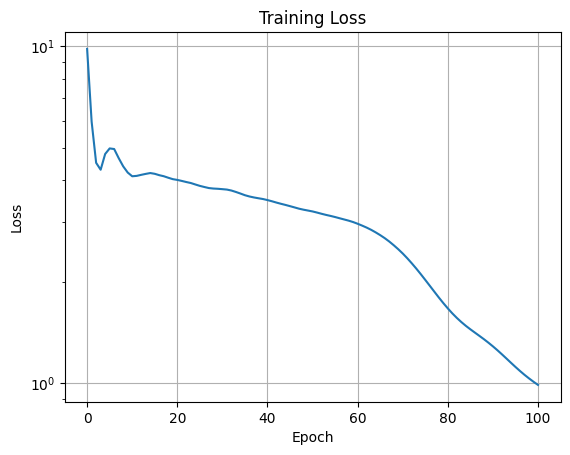

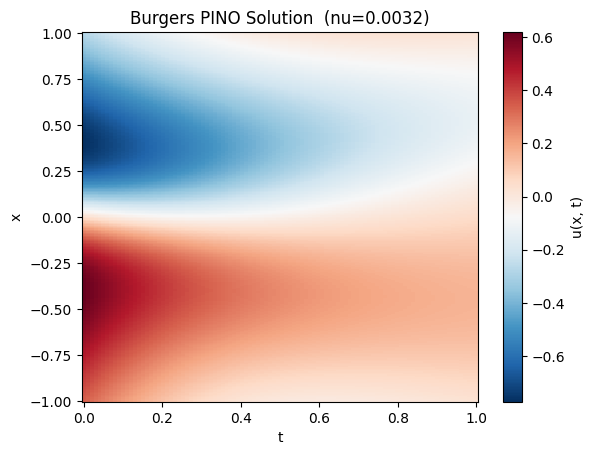

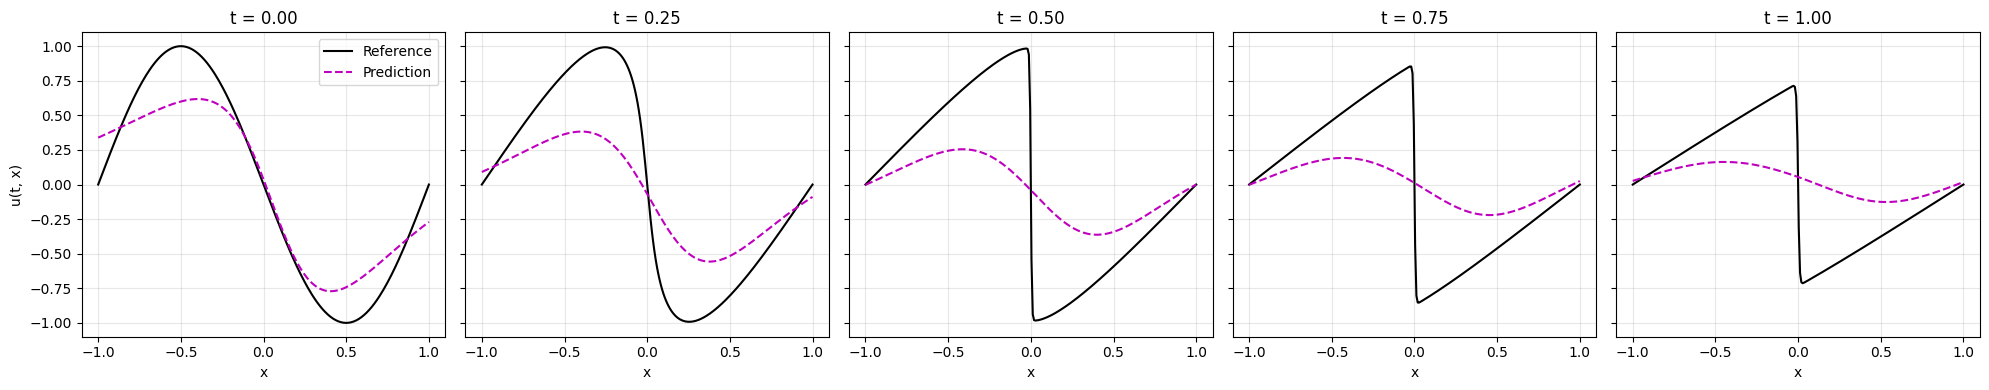

In [8]:
plot_loss(history_pino)
plot_solution(model_pino, nu_val=nu)
plot_slices(model_pino, nu_val=nu)

## PI-FNO — physics-informed Fourier neural operator

The FNO maps the initial condition **u₀(x)** directly to the full space-time trajectory **u(x, t)** on a fixed grid, using spectral convolution layers (FFT → learnable mode weights → IFFT) instead of pointwise MLPs.  Physics loss is enforced via central finite differences on the predicted grid.

In [9]:
model_fno = build_fno_model(NX_FNO, NT_FNO, width=FNO_WIDTH, n_modes=FNO_MODES, n_layers=FNO_DEPTH)
model_fno.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128, 32)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fno_block1d (FNOBlock1D)        │ (None, 128, 32)        │        33,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fno_block1d_1 (FNOBlock1D)      │ (None, 128, 32)        │        33,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fno_block1d_2 (FNOBlock1D)      │ (None, 128, 32)        │        33,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fno_block1d_3 (FNOBlock1D)      │ (None, 128, 32)        │        33,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128, 128)       │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128, 50)        │         6,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146,066 (570.57 KB)

 Trainable params: 146,066 (570.57 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
import tensorflow as tf

fno_data = get_fno_data(NX_FNO, NT_FNO)   # (u0, x_grid, t_grid)

LR_fno = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=500,
    decay_rate=0.95)

optim_fno  = tf.keras.optimizers.Adam(learning_rate=LR_fno)
trainer_fno = PIFNOTrainer(model_fno, optim_fno, nu, NX_FNO, NT_FNO)

history_fno = []
for epoch in range(1, Epochs + 1):
    loss = trainer_fno.train_step(fno_data)
    history_fno.append(float(loss))
    if epoch % 100 == 0:
        print(f"Epoch: {epoch:5d}, Loss: {float(loss):.4e}")

Epoch:   100, Loss: 1.6988e-01


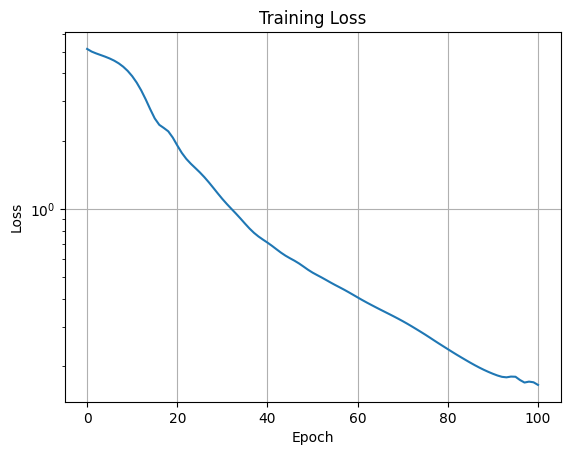

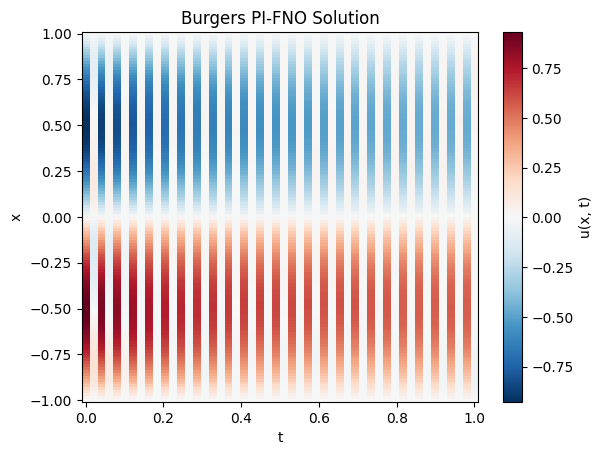

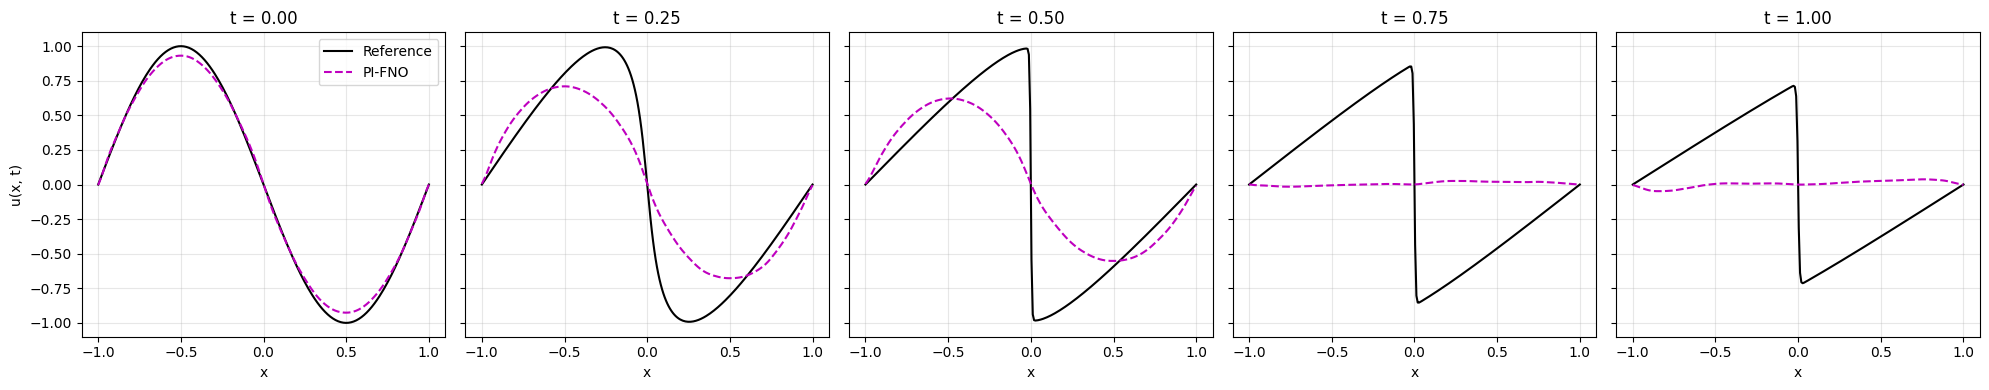

In [11]:
plot_loss(history_fno)
plot_fno_solution(model_fno, nx=NX_FNO, nt=NT_FNO)
plot_fno_slices(model_fno, nx=NX_FNO, nt=NT_FNO)

---
## Model Evaluation & Validation

Five scenarios across three regimes:

| # | Regime | ν |
|---|--------|---|
| 1 | **Seen** — training nu for PINN & PI-FNO | `0.01 / π` |
| 2 | **Interpolation** — within PINO training range | `1 / π`, `0.001` |
| 3 | **Extrapolation** — outside PINO training range | `3 / π`, `0.0005 / π` |

Each scenario shows: training-loss history (once), x-t contour maps, and 5 time-slice comparisons for all three models vs. the high-fidelity Radau reference.

In [12]:
from evaluator import (load_or_generate_reference,
                       predict_pinn, predict_pino, predict_fno,
                       rel_l2, time_predict, peak_memory_mb, param_mb)
from visualizer import plot_loss_comparison, plot_eval
import pandas as pd
import os

# Common evaluation grid (matches reference resolution)
X_EVAL = np.linspace(-1, 1, 256).astype(np.float32)
T_EVAL = np.linspace(0,  1, 201).astype(np.float32)

# Evaluation scenarios: label -> nu value
SCENARIOS = {
    'Seen      | nu=0.01/pi':    0.01   / np.pi,   # PINN & PI-FNO training nu
    'Interp    | nu=1/pi':       1.0    / np.pi,   # top of PINO training range
    'Interp    | nu=0.001':      0.001,             # between PINO training points
    'Extrap HI | nu=3/pi':       3.0    / np.pi,   # above PINO max (1/pi)
    'Extrap LO | nu=0.0005/pi':  0.0005 / np.pi,   # below PINO min (0.0001/pi)
}

# Colab mounts repo under /content; elsewhere use a local folder
CACHE_DIR = '/content/ref_cache' if os.path.exists('/content') else 'ref_cache'

print("Loading reference solutions (cached) or generating if not yet saved ...\n")
references = {}
for label, nu_val in SCENARIOS.items():
    print(f"  {label}  (nu={nu_val:.6f}) ... ", end='', flush=True)
    x_ref, t_ref, u_ref = load_or_generate_reference(nu_val, cache_dir=CACHE_DIR)
    references[label] = (nu_val, x_ref, t_ref, u_ref)
    print("done")
print("\nAll reference solutions ready.")

Loading reference solutions (cached) or generating if not yet saved ...

  Seen      | nu=0.01/pi  (nu=0.003183) ... done
  Interp    | nu=1/pi  (nu=0.318310) ... done
  Interp    | nu=0.001  (nu=0.001000) ... done
  Extrap HI | nu=3/pi  (nu=0.954930) ... done
  Extrap LO | nu=0.0005/pi  (nu=0.000159) ... done

All reference solutions ready.


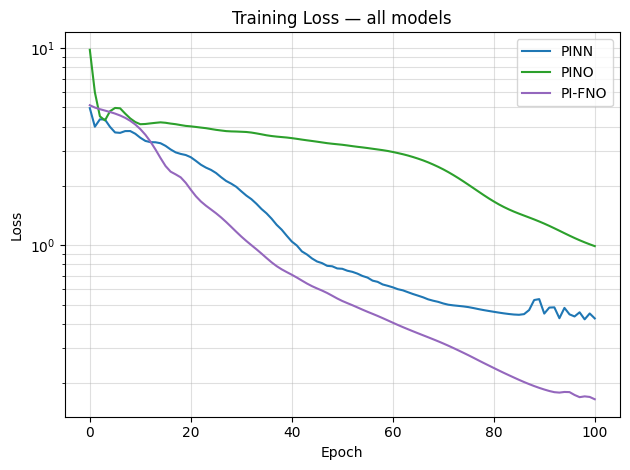

In [13]:
# Training loss comparison (shown once — independent of evaluation scenario)
plot_loss_comparison(
    [history, history_pino, history_fno],
    labels=['PINN', 'PINO', 'PI-FNO']
)


  Scenario: Seen      | nu=0.01/pi


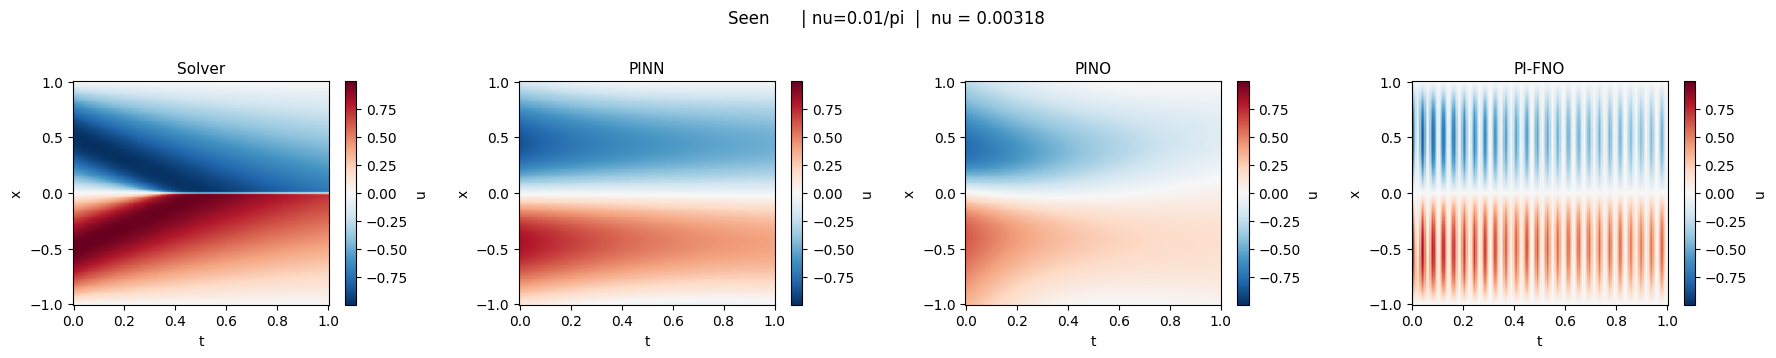

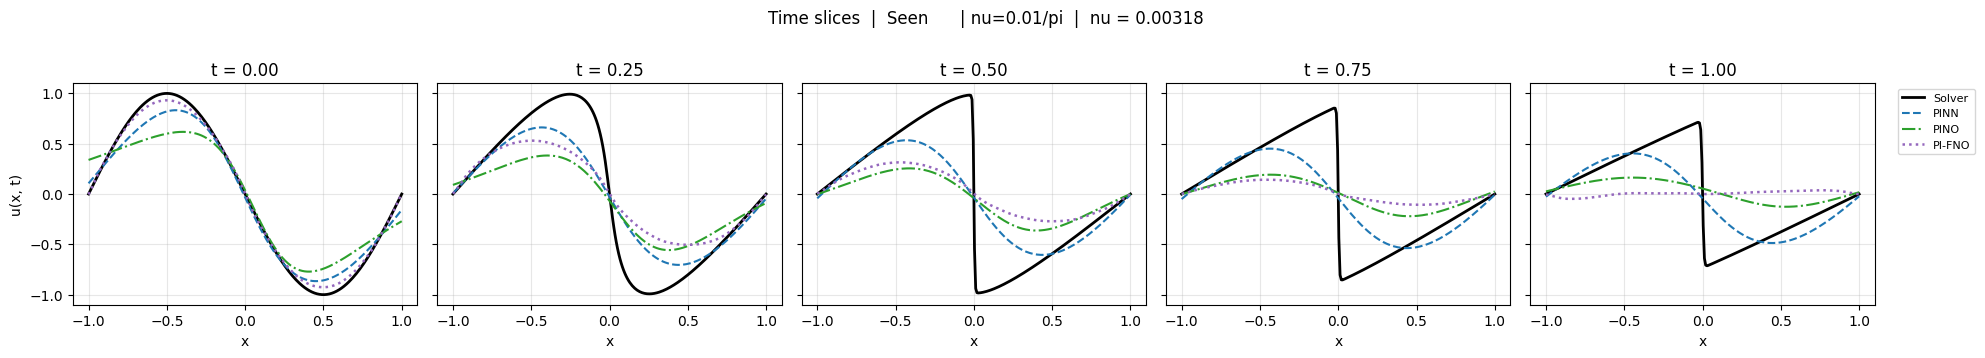

  PINN      rel-L2 = 4.7086e-01
  PINO      rel-L2 = 6.4663e-01
  PI-FNO    rel-L2 = 7.1936e-01

  Scenario: Interp    | nu=1/pi


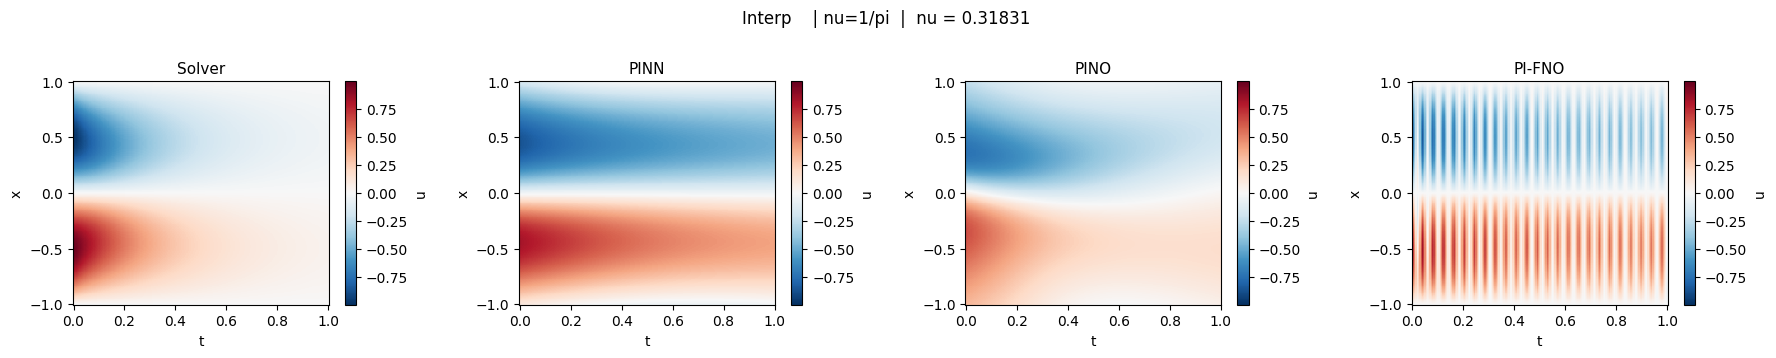

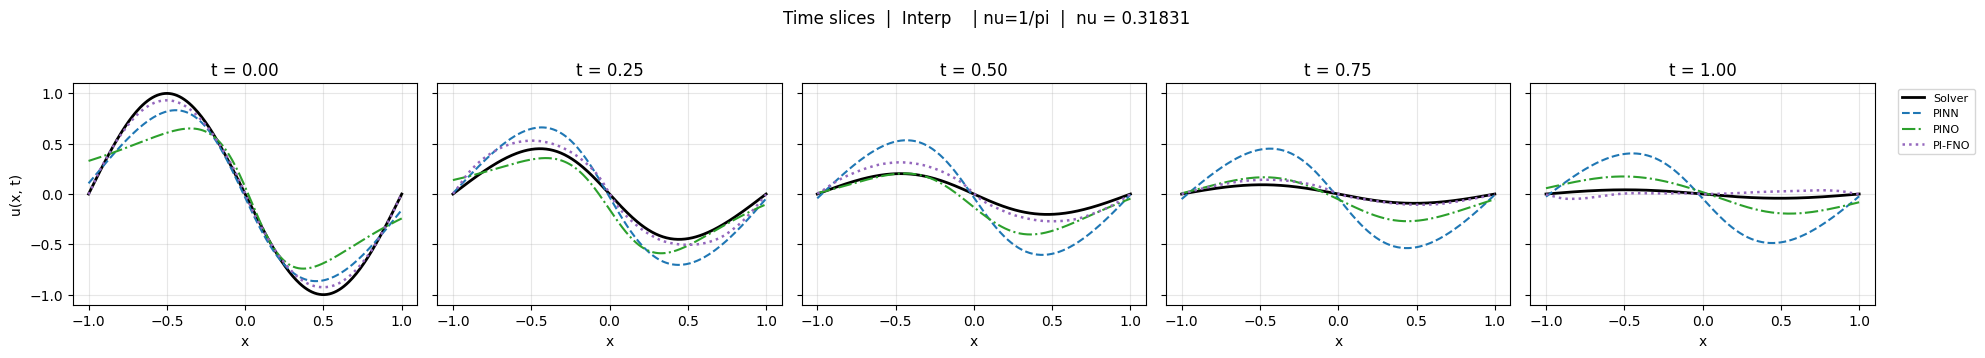

  PINN      rel-L2 = 8.3612e-01
  PINO      rel-L2 = 4.0937e-01
  PI-FNO    rel-L2 = 7.0531e-01

  Scenario: Interp    | nu=0.001


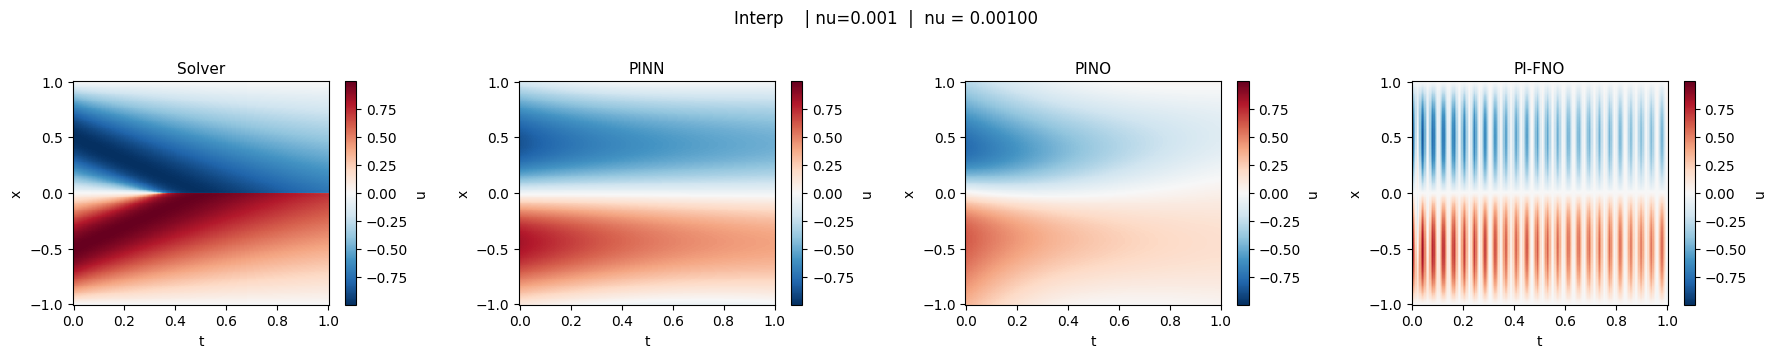

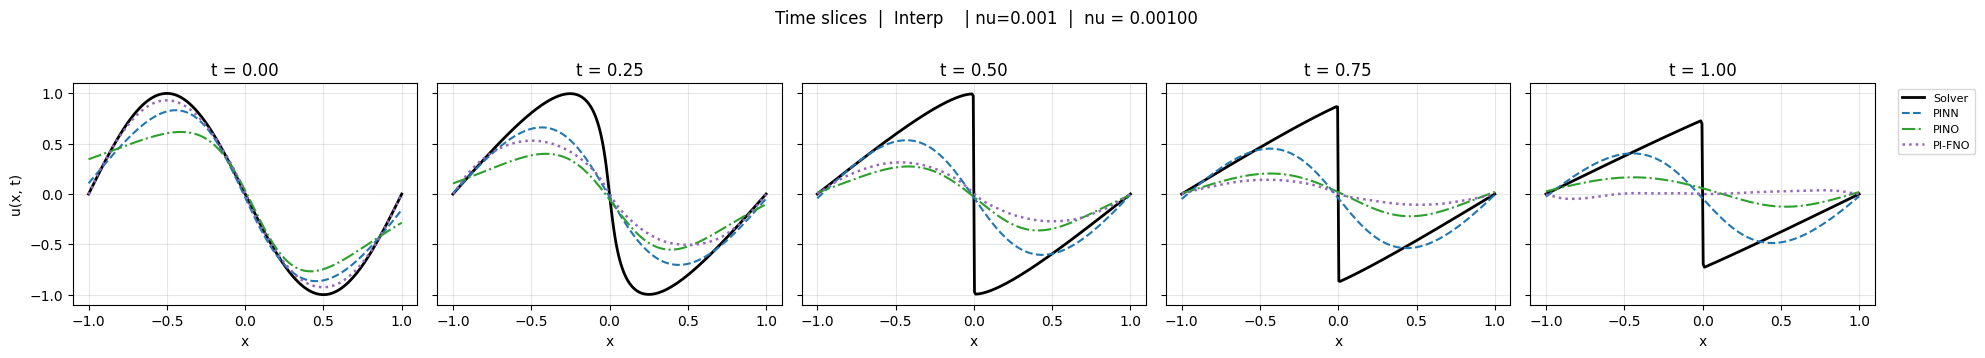

  PINN      rel-L2 = 4.8110e-01
  PINO      rel-L2 = 6.4667e-01
  PI-FNO    rel-L2 = 7.2376e-01

  Scenario: Extrap HI | nu=3/pi


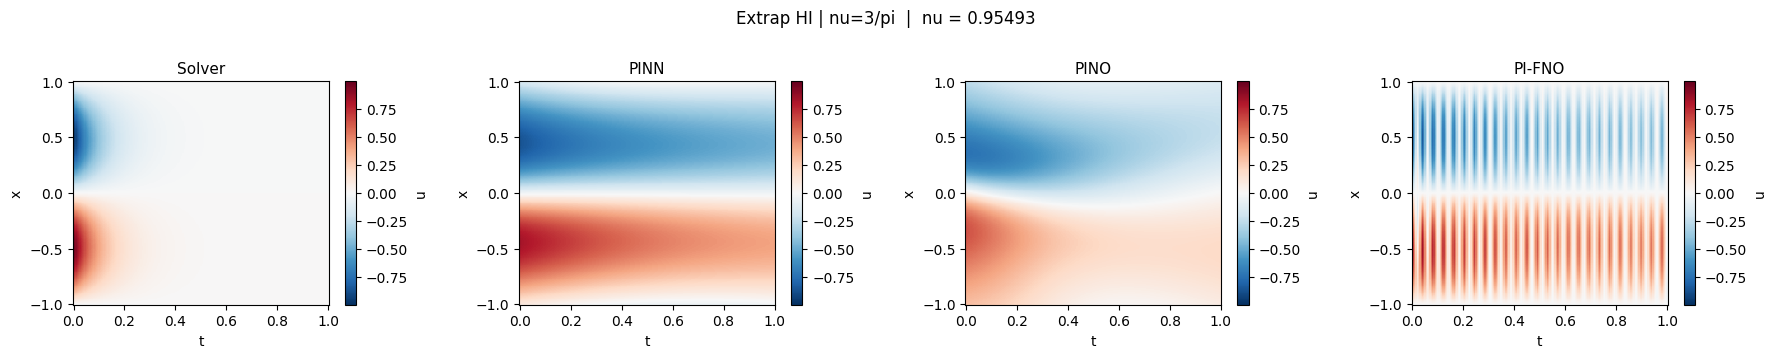

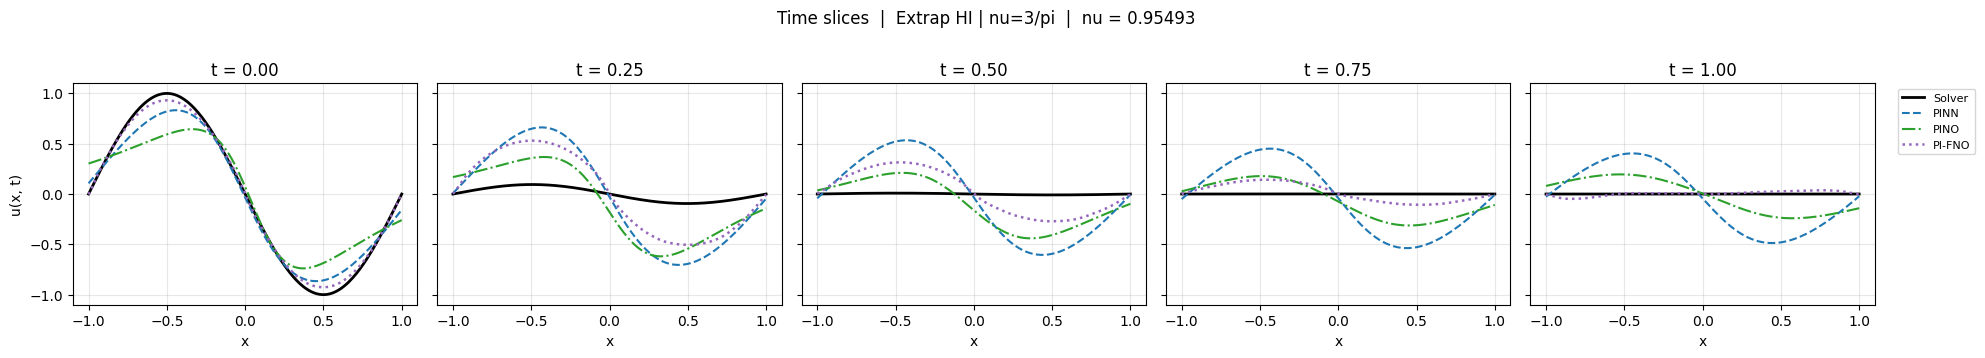

  PINN      rel-L2 = 2.1678e+00
  PINO      rel-L2 = 1.3997e+00
  PI-FNO    rel-L2 = 1.4043e+00

  Scenario: Extrap LO | nu=0.0005/pi


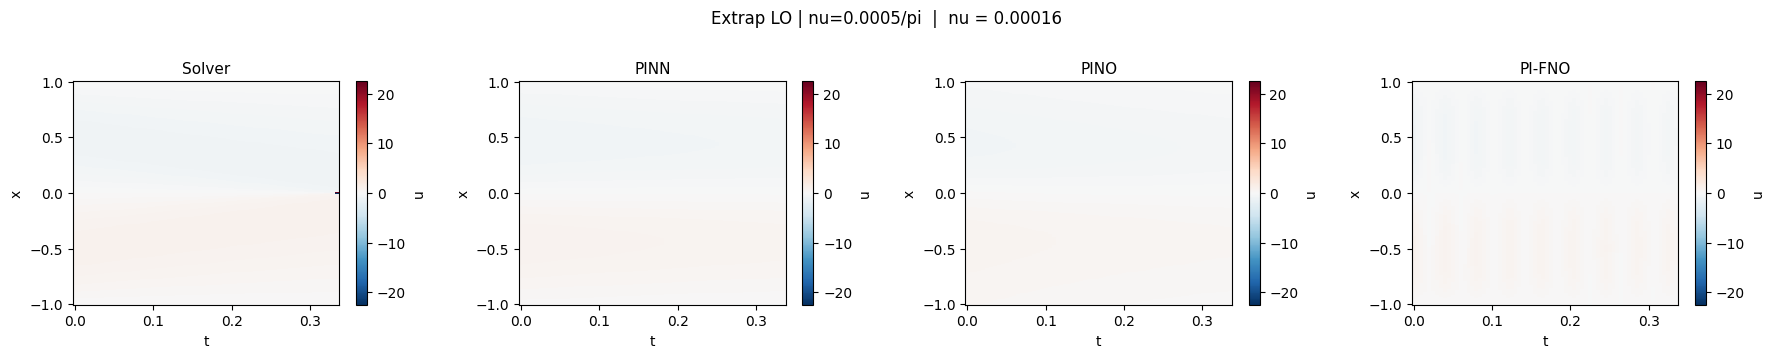

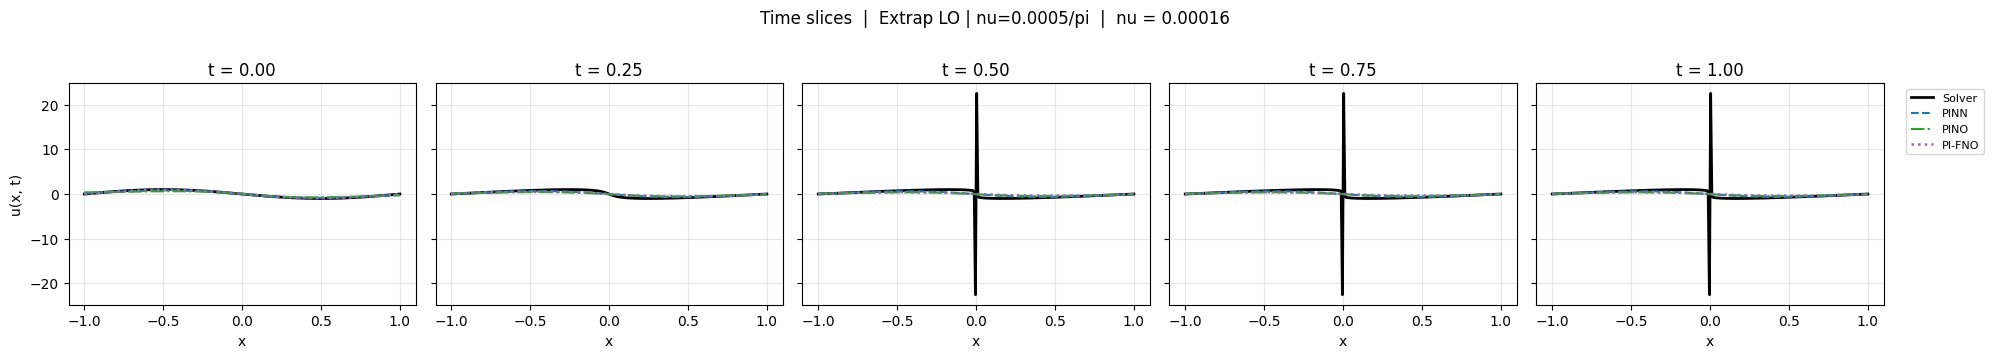

  PINN      rel-L2 = 4.4955e-01
  PINO      rel-L2 = 5.5247e-01
  PI-FNO    rel-L2 = 7.0630e-01


In [14]:
# Scenario evaluation — contour maps + time slices for all 4 competitors
# eval_results collects L2 errors for the summary table.

from evaluator import predict_solver

eval_results = {}   # (model_name, scenario_label) -> rel L2 error

for label, (nu_val, x_ref, t_ref, u_ref) in references.items():
    print(f"\n{'='*65}")
    print(f"  Scenario: {label}")
    print(f"{'='*65}")

    u_pinn   = predict_pinn(model,      x_ref, t_ref)
    u_pino   = predict_pino(model_pino, x_ref, t_ref, nu_val)
    u_fno    = predict_fno( model_fno,  x_ref, t_ref, NX_FNO, NT_FNO)
    # Solver output == reference by construction (L2 = 0)

    preds = {
        'Solver':  u_ref,    # numerical solver IS the reference
        'PINN':    u_pinn,
        'PINO':    u_pino,
        'PI-FNO':  u_fno,
    }

    plot_eval(preds, x_ref, t_ref, nu_val, label)

    eval_results[('Solver', label)] = 0.0   # exact by definition
    for name, u_pred in [('PINN', u_pinn), ('PINO', u_pino), ('PI-FNO', u_fno)]:
        err = rel_l2(u_pred, u_ref)
        eval_results[(name, label)] = err
        print(f"  {name:8s}  rel-L2 = {err:.4e}")

In [15]:
# Timing and memory profiling — all 4 competitors
#
# Neural models: 5-run mean after JIT warmup  (milliseconds)
# Numerical solver: single fresh Radau solve, no warmup (seconds → shown in ms too)

from evaluator import time_predict, peak_memory_mb, param_mb, predict_solver

N_RUNS   = 5
_x, _t  = X_EVAL, T_EVAL
_nu_ref  = nu   # 0.01/pi

timing_cases = [
    # (display name,  model or None,  predict_fn,       n_runs, warmup)
    ('Solver',  None,       lambda: predict_solver(_nu_ref, nx=256, nt=201), 1,      False),
    ('PINN',    model,      lambda: predict_pinn(model,      _x, _t),        N_RUNS, True),
    ('PINO',    model_pino, lambda: predict_pino(model_pino, _x, _t, _nu_ref), N_RUNS, True),
    ('PI-FNO',  model_fno,  lambda: predict_fno(model_fno,   _x, _t, NX_FNO, NT_FNO), N_RUNS, True),
]

timing = {}
for name, mdl, fn, n, w in timing_cases:
    t_s  = time_predict(fn, n_runs=n, warmup=w)
    mem  = peak_memory_mb(fn)
    pmb  = param_mb(mdl) if mdl is not None else 0.0
    timing[name] = {'time_ms': t_s * 1000, 'peak_ram_mb': mem, 'params_mb': pmb}
    runs_note = f"(n=1, no warmup)" if not w else f"(n={n}, mean)"
    print(f"{name:8s}  time={t_s*1000:9.2f} ms  "
          f"peak RAM={mem:6.2f} MB  params={pmb:.3f} MB  {runs_note}")

Solver    time= 10072.44 ms  peak RAM= 81.85 MB  params=0.000 MB  (n=1, no warmup)
PINN      time=    13.55 ms  peak RAM=  0.99 MB  params=0.005 MB  (n=5, mean)
PINO      time=    13.90 ms  peak RAM=  1.19 MB  params=0.005 MB  (n=5, mean)
PI-FNO    time=    28.31 ms  peak RAM=  6.69 MB  params=0.557 MB  (n=5, mean)


In [16]:
# Summary comparison table — all 4 competitors across all 5 scenarios
rows = []
for label, (nu_val, *_) in references.items():
    for model_name in ['Solver', 'PINN', 'PINO', 'PI-FNO']:
        t = timing[model_name]
        rows.append({
            'Scenario':       label,
            'Model':          model_name,
            'nu':             f'{nu_val:.6f}',
            'Rel. L2 Error':  f"{eval_results[(model_name, label)]:.3e}",
            'Infer. (ms)':    f"{t['time_ms']:.2f}",
            'Params (MB)':    f"{t['params_mb']:.3f}",
            'Peak RAM (MB)':  f"{t['peak_ram_mb']:.2f}",
        })

df = pd.DataFrame(rows).set_index(['Scenario', 'Model'])

def highlight_best(s):
    """Green on the lowest L2 error per group of 4 (one row = one scenario × model)."""
    vals = s.map(lambda v: float(v.replace('e+', 'e').replace('e-', 'e-')))
    is_best = vals == vals.min()
    return ['background-color: #c6efce; font-weight: bold' if v else '' for v in is_best]

display(
    df.style
    .apply(highlight_best, subset=['Rel. L2 Error'])
    .set_caption('Model Comparison — Rel. L2 Error  /  Inference Time  /  Memory')
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
)